<a href="https://colab.research.google.com/github/mohiuddin2806-lang/machine-learning-/blob/main/week9mohi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [4]:
park = SparkSession.builder \
    .master("local[*]") \
    .appName("Bitcoin Forecasting using PySpark") \
    .getOrCreate()
print("Spark Version:", park.version)

Spark Version: 4.0.4


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
spark_df = park.read.csv(
    "/content/btcusd_1-min_data.csv",
    header=True,
    inferSchema=True
)
spark_df.show(5)

+----------+----+----+----+-----+------+
| Timestamp|Open|High| Low|Close|Volume|
+----------+----+----+----+-----+------+
|1325376060|4.58|4.58|4.58| 4.58|   0.0|
|1325376120|4.58|4.58|4.58| 4.58|   0.0|
|1325376180|4.58|4.58|4.58| 4.58|   0.0|
|1325376240|4.58|4.58|4.58| 4.58|   0.0|
|1325376300|4.58|4.58|4.58| 4.58|   0.0|
+----------+----+----+----+-----+------+
only showing top 5 rows


In [10]:
spark_df.printSchema()
print("Number of Rows :", spark_df.count())
print("Number of Columns :", len(spark_df.columns))

root
 |-- Timestamp: integer (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)

Number of Rows : 943772
Number of Columns : 6


In [14]:
from pyspark.sql.functions import col,isnan,when,count

null_counts_expressions = [count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in spark_df.columns]
spark_df.select(null_counts_expressions).show()

+---------+----+----+---+-----+------+
|Timestamp|Open|High|Low|Close|Volume|
+---------+----+----+---+-----+------+
|        0|   0|   0|  0|    0|     0|
+---------+----+----+---+-----+------+



In [13]:
spark_df = spark_df.dropna()
print("Rows after removing missing values:")
print(spark_df.count())

Rows after removing missing values:
943771


In [15]:
spark_df = spark_df.withColumn(
"Date",
from_unixtime(col("Timestamp")).cast("timestamp")
)
spark_df.select("Timestamp","Date").show(5,False)

+----------+-------------------+
|Timestamp |Date               |
+----------+-------------------+
|1325376060|2012-01-01 00:01:00|
|1325376120|2012-01-01 00:02:00|
|1325376180|2012-01-01 00:03:00|
|1325376240|2012-01-01 00:04:00|
|1325376300|2012-01-01 00:05:00|
+----------+-------------------+
only showing top 5 rows


In [16]:
spark_df = spark_df.orderBy("Date")

In [17]:
spark_df.select("Date","Close").show(10,False)

+-------------------+-----+
|Date               |Close|
+-------------------+-----+
|2012-01-01 00:01:00|4.58 |
|2012-01-01 00:02:00|4.58 |
|2012-01-01 00:03:00|4.58 |
|2012-01-01 00:04:00|4.58 |
|2012-01-01 00:05:00|4.58 |
|2012-01-01 00:06:00|4.58 |
|2012-01-01 00:07:00|4.58 |
|2012-01-01 00:08:00|4.58 |
|2012-01-01 00:09:00|4.58 |
|2012-01-01 00:10:00|4.58 |
+-------------------+-----+
only showing top 10 rows


In [18]:
spark_df.describe().show()

+-------+--------------------+-----------------+------------------+-----------------+-----------------+------------------+
|summary|           Timestamp|             Open|              High|              Low|            Close|            Volume|
+-------+--------------------+-----------------+------------------+-----------------+-----------------+------------------+
|  count|              943771|           943771|            943771|           943771|           943771|            943771|
|   mean|        1.35368916E9|43.17703883675026|43.197481412332486|43.15210668689536|43.17495116929571|3.5241950317327486|
| stddev|1.6346601887352614E7|48.37833188815369| 48.40745225002957|48.34186723538482|48.37455360190846| 22.79060646728792|
|    min|          1325376060|              3.8|               3.8|              3.8|              3.8|               0.0|
|    max|          1382002260|           259.34|            259.34|           259.34|           259.34|     2958.47757418|
+-------+-------

In [19]:
sample_df = spark_df.limit(5000).toPandas()
sample_df.head()

,Timestamp,Open,High,Low,Close,Volume,Date
0,1325376060,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:01:00
1,1325376120,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:02:00
2,1325376180,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:03:00
3,1325376240,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:04:00
4,1325376300,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:05:00


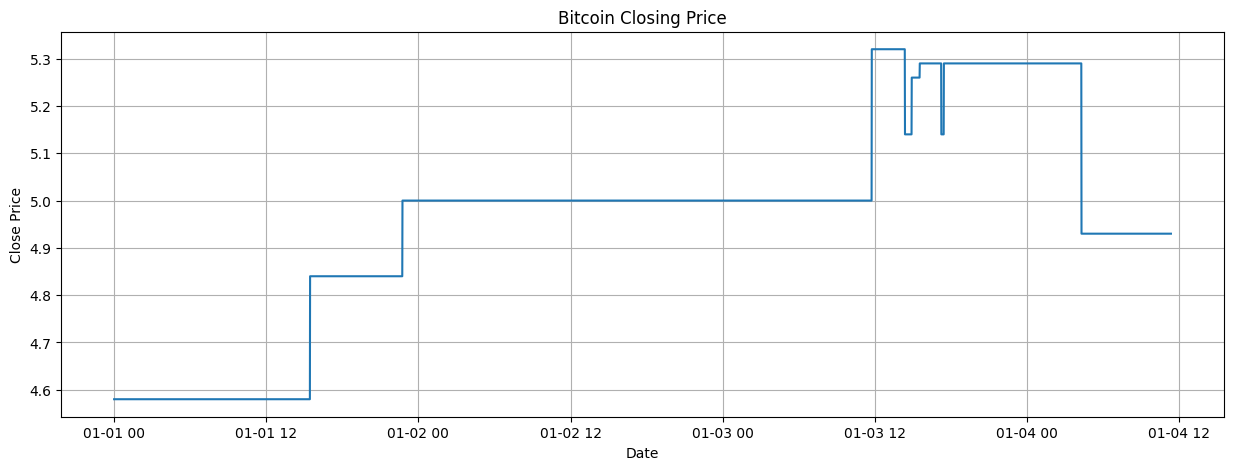

In [20]:
plt.figure(figsize=(15,5))
plt.plot(sample_df["Date"],
sample_df["Close"])
plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

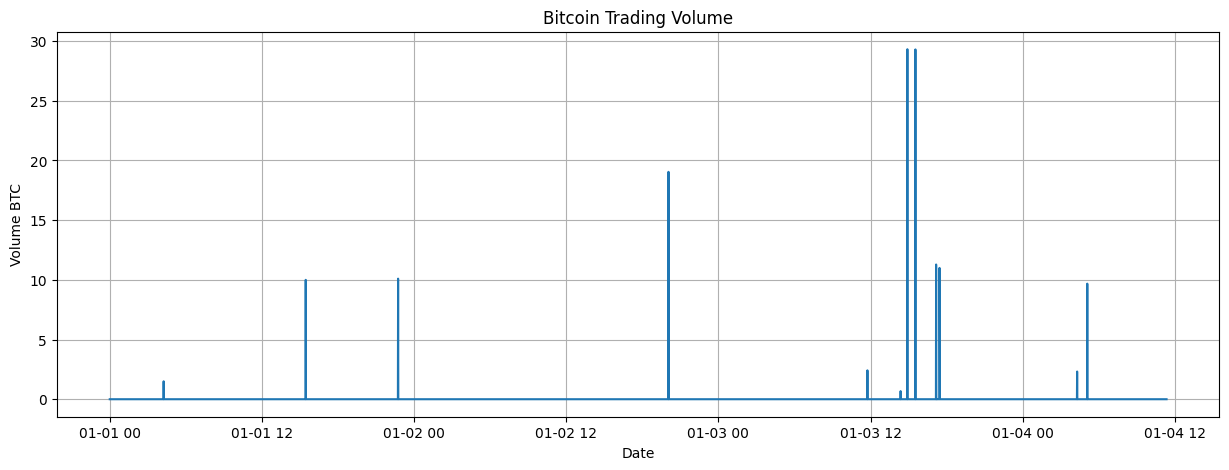

In [21]:
plt.figure(figsize=(15,5))
plt.plot(sample_df["Date"],
sample_df["Volume"])
plt.title("Bitcoin Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume BTC")
plt.grid(True)
plt.show()

In [22]:
pdf = sample_df[[
"Open",
"High",
"Low",
"Close",
"Volume" # Corrected from 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price'
]]
corr = pdf.corr()
corr

,Open,High,Low,Close,Volume
Open,1.000000,1.000000,1.000000,1.000000,0.033443
High,1.000000,1.000000,1.000000,1.000000,0.033443
Low,1.000000,1.000000,1.000000,1.000000,0.033443
Close,1.000000,1.000000,1.000000,1.000000,0.033443
Volume,0.033443,0.033443,0.033443,0.033443,1.000000


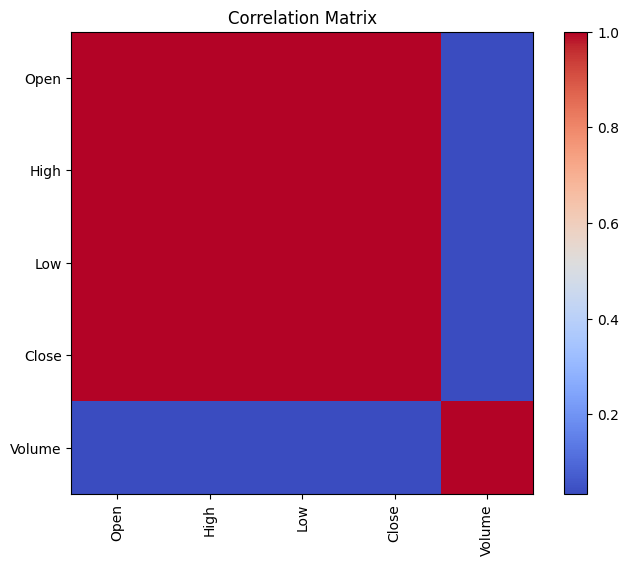

In [23]:
pdf = sample_df[[
"Open",
"High",
"Low",
"Close",
"Volume"
]]
corr = pdf.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr,
cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)),
corr.columns,
rotation=90)
plt.yticks(range(len(corr.columns)),
corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [24]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *
windowSpec = Window.orderBy("Date")

In [25]:
spark_df = spark_df \
.withColumn("Lag_1", lag("Close", 1).over(windowSpec)) \
.withColumn("Lag_2", lag("Close", 2).over(windowSpec)) \
.withColumn("Lag_3", lag("Close", 3).over(windowSpec))
spark_df.select(
"Date",
"Close",
"Lag_1",
"Lag_2",
"Lag_3"
).show(10, False)

+-------------------+-----+-----+-----+-----+
|Date               |Close|Lag_1|Lag_2|Lag_3|
+-------------------+-----+-----+-----+-----+
|2012-01-01 00:01:00|4.58 |NULL |NULL |NULL |
|2012-01-01 00:02:00|4.58 |4.58 |NULL |NULL |
|2012-01-01 00:03:00|4.58 |4.58 |4.58 |NULL |
|2012-01-01 00:04:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:05:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:06:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:07:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:08:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:09:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:10:00|4.58 |4.58 |4.58 |4.58 |
+-------------------+-----+-----+-----+-----+
only showing top 10 rows


In [26]:
rollingWindow = Window.orderBy("Date").rowsBetween(-4,0)

In [27]:
spark_df = spark_df.withColumn(
"Rolling_Mean",
avg("Close").over(rollingWindow)
)
spark_df.select(
"Date",
"Close",
"Rolling_Mean"
).show(10, False)

+-------------------+-----+------------+
|Date               |Close|Rolling_Mean|
+-------------------+-----+------------+
|2012-01-01 00:01:00|4.58 |4.58        |
|2012-01-01 00:02:00|4.58 |4.58        |
|2012-01-01 00:03:00|4.58 |4.58        |
|2012-01-01 00:04:00|4.58 |4.58        |
|2012-01-01 00:05:00|4.58 |4.58        |
|2012-01-01 00:06:00|4.58 |4.58        |
|2012-01-01 00:07:00|4.58 |4.58        |
|2012-01-01 00:08:00|4.58 |4.58        |
|2012-01-01 00:09:00|4.58 |4.58        |
|2012-01-01 00:10:00|4.58 |4.58        |
+-------------------+-----+------------+
only showing top 10 rows


In [28]:
spark_df = spark_df.withColumn(
"Rolling_STD",
stddev("Close").over(rollingWindow)
)
spark_df.select(
"Date",
"Close",
"Rolling_STD"
).show(10, False)

+-------------------+-----+-----------+
|Date               |Close|Rolling_STD|
+-------------------+-----+-----------+
|2012-01-01 00:01:00|4.58 |NULL       |
|2012-01-01 00:02:00|4.58 |0.0        |
|2012-01-01 00:03:00|4.58 |0.0        |
|2012-01-01 00:04:00|4.58 |0.0        |
|2012-01-01 00:05:00|4.58 |0.0        |
|2012-01-01 00:06:00|4.58 |0.0        |
|2012-01-01 00:07:00|4.58 |0.0        |
|2012-01-01 00:08:00|4.58 |0.0        |
|2012-01-01 00:09:00|4.58 |0.0        |
|2012-01-01 00:10:00|4.58 |0.0        |
+-------------------+-----+-----------+
only showing top 10 rows


In [29]:
spark_df = spark_df.withColumn(
"Rolling_Max",
max("Close").over(rollingWindow)
)
spark_df.select(
"Date",
"Close",
"Rolling_Max"
).show(10, False)

+-------------------+-----+-----------+
|Date               |Close|Rolling_Max|
+-------------------+-----+-----------+
|2012-01-01 00:01:00|4.58 |4.58       |
|2012-01-01 00:02:00|4.58 |4.58       |
|2012-01-01 00:03:00|4.58 |4.58       |
|2012-01-01 00:04:00|4.58 |4.58       |
|2012-01-01 00:05:00|4.58 |4.58       |
|2012-01-01 00:06:00|4.58 |4.58       |
|2012-01-01 00:07:00|4.58 |4.58       |
|2012-01-01 00:08:00|4.58 |4.58       |
|2012-01-01 00:09:00|4.58 |4.58       |
|2012-01-01 00:10:00|4.58 |4.58       |
+-------------------+-----+-----------+
only showing top 10 rows


In [30]:
spark_df = spark_df.withColumn(
"Rolling_Min",
min("Close").over(rollingWindow)
)
spark_df.select(
"Date",
"Close",
"Rolling_Min"
).show(10, False)

+-------------------+-----+-----------+
|Date               |Close|Rolling_Min|
+-------------------+-----+-----------+
|2012-01-01 00:01:00|4.58 |4.58       |
|2012-01-01 00:02:00|4.58 |4.58       |
|2012-01-01 00:03:00|4.58 |4.58       |
|2012-01-01 00:04:00|4.58 |4.58       |
|2012-01-01 00:05:00|4.58 |4.58       |
|2012-01-01 00:06:00|4.58 |4.58       |
|2012-01-01 00:07:00|4.58 |4.58       |
|2012-01-01 00:08:00|4.58 |4.58       |
|2012-01-01 00:09:00|4.58 |4.58       |
|2012-01-01 00:10:00|4.58 |4.58       |
+-------------------+-----+-----------+
only showing top 10 rows


In [31]:
spark_df = spark_df.withColumn(
"Rolling_Range",
col("Rolling_Max") - col("Rolling_Min")
)
spark_df.select(
"Date",
"Rolling_Range"
).show(10, False)

+-------------------+-------------+
|Date               |Rolling_Range|
+-------------------+-------------+
|2012-01-01 00:01:00|0.0          |
|2012-01-01 00:02:00|0.0          |
|2012-01-01 00:03:00|0.0          |
|2012-01-01 00:04:00|0.0          |
|2012-01-01 00:05:00|0.0          |
|2012-01-01 00:06:00|0.0          |
|2012-01-01 00:07:00|0.0          |
|2012-01-01 00:08:00|0.0          |
|2012-01-01 00:09:00|0.0          |
|2012-01-01 00:10:00|0.0          |
+-------------------+-------------+
only showing top 10 rows


In [32]:
spark_df = spark_df.withColumn(
"Price_Change",
col("Close") - col("Lag_1")
)
spark_df.select(
"Date",
"Price_Change"
).show(10, False)

+-------------------+------------+
|Date               |Price_Change|
+-------------------+------------+
|2012-01-01 00:01:00|NULL        |
|2012-01-01 00:02:00|0.0         |
|2012-01-01 00:03:00|0.0         |
|2012-01-01 00:04:00|0.0         |
|2012-01-01 00:05:00|0.0         |
|2012-01-01 00:06:00|0.0         |
|2012-01-01 00:07:00|0.0         |
|2012-01-01 00:08:00|0.0         |
|2012-01-01 00:09:00|0.0         |
|2012-01-01 00:10:00|0.0         |
+-------------------+------------+
only showing top 10 rows


In [33]:
spark_df = spark_df.withColumn(
"Return",
((col("Close") - col("Lag_1")) / col("Lag_1")) * 100
)
spark_df.select(
"Date",
"Return"
).show(10, False)

+-------------------+------+
|Date               |Return|
+-------------------+------+
|2012-01-01 00:01:00|NULL  |
|2012-01-01 00:02:00|0.0   |
|2012-01-01 00:03:00|0.0   |
|2012-01-01 00:04:00|0.0   |
|2012-01-01 00:05:00|0.0   |
|2012-01-01 00:06:00|0.0   |
|2012-01-01 00:07:00|0.0   |
|2012-01-01 00:08:00|0.0   |
|2012-01-01 00:09:00|0.0   |
|2012-01-01 00:10:00|0.0   |
+-------------------+------+
only showing top 10 rows


In [34]:
spark_df = spark_df.withColumn(
"Target",
lead("Close",1).over(windowSpec)
)
spark_df.select(
"Date",
"Close",
"Target"
).show(10, False)

+-------------------+-----+------+
|Date               |Close|Target|
+-------------------+-----+------+
|2012-01-01 00:01:00|4.58 |4.58  |
|2012-01-01 00:02:00|4.58 |4.58  |
|2012-01-01 00:03:00|4.58 |4.58  |
|2012-01-01 00:04:00|4.58 |4.58  |
|2012-01-01 00:05:00|4.58 |4.58  |
|2012-01-01 00:06:00|4.58 |4.58  |
|2012-01-01 00:07:00|4.58 |4.58  |
|2012-01-01 00:08:00|4.58 |4.58  |
|2012-01-01 00:09:00|4.58 |4.58  |
|2012-01-01 00:10:00|4.58 |4.58  |
+-------------------+-----+------+
only showing top 10 rows


In [ ]:
spark_df = spark_df.dropna()
print("Remaining Rows:", spark_df.count())

In [35]:
spark_df.select(
"Date",
"Close",
"Lag_1",
"Lag_2",
"Lag_3",
"Rolling_Mean",
"Rolling_STD",
"Rolling_Max",
"Rolling_Min",
"Rolling_Range",
"Price_Change",
"Return",
"Target"
).show(15, False)

+-------------------+-----+-----+-----+-----+------------+-----------+-----------+-----------+-------------+------------+------+------+
|Date               |Close|Lag_1|Lag_2|Lag_3|Rolling_Mean|Rolling_STD|Rolling_Max|Rolling_Min|Rolling_Range|Price_Change|Return|Target|
+-------------------+-----+-----+-----+-----+------------+-----------+-----------+-----------+-------------+------------+------+------+
|2012-01-01 00:01:00|4.58 |NULL |NULL |NULL |4.58        |NULL       |4.58       |4.58       |0.0          |NULL        |NULL  |4.58  |
|2012-01-01 00:02:00|4.58 |4.58 |NULL |NULL |4.58        |0.0        |4.58       |4.58       |0.0          |0.0         |0.0   |4.58  |
|2012-01-01 00:03:00|4.58 |4.58 |4.58 |NULL |4.58        |0.0        |4.58       |4.58       |0.0          |0.0         |0.0   |4.58  |
|2012-01-01 00:04:00|4.58 |4.58 |4.58 |4.58 |4.58        |0.0        |4.58       |4.58       |0.0          |0.0         |0.0   |4.58  |
|2012-01-01 00:05:00|4.58 |4.58 |4.58 |4.58 |4.5

In [36]:
spark_df.printSchema()

root
 |-- Timestamp: integer (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Lag_1: double (nullable = true)
 |-- Lag_2: double (nullable = true)
 |-- Lag_3: double (nullable = true)
 |-- Rolling_Mean: double (nullable = true)
 |-- Rolling_STD: double (nullable = true)
 |-- Rolling_Max: double (nullable = true)
 |-- Rolling_Min: double (nullable = true)
 |-- Rolling_Range: double (nullable = true)
 |-- Price_Change: double (nullable = true)
 |-- Return: double (nullable = true)
 |-- Target: double (nullable = true)



In [37]:
feature_columns = [
"Open",
"High",
"Low",
"Volume_(BTC)",
"Volume_(Currency)",
"Weighted_Price",
"Lag_1",
"Lag_2",
"Lag_3",
"Rolling_Mean",
"Rolling_STD",
"Rolling_Max",
"Rolling_Min",
"Rolling_Range",
"Price_Change",
"Return"
]
label_column = "Target"
print("Number of Features:", len(feature_columns))
print(feature_columns)

Number of Features: 16
['Open', 'High', 'Low', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean', 'Rolling_STD', 'Rolling_Max', 'Rolling_Min', 'Rolling_Range', 'Price_Change', 'Return']


In [39]:
from pyspark.ml.feature import VectorAssembler
# Redefine feature_columns to use the correct column names
feature_columns = [
"Open",
"High",
"Low",
"Volume", # Corrected from 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price'
"Lag_1",
"Lag_2",
"Lag_3",
"Rolling_Mean",
"Rolling_STD",
"Rolling_Max",
"Rolling_Min",
"Rolling_Range",
"Price_Change",
"Return"
]
assembler = VectorAssembler(
inputCols=feature_columns,
outputCol="features",
handleInvalid="skip" # Add this parameter to handle null values by skipping rows
)
assembled_df = assembler.transform(spark_df)
assembled_df.select("features", "Target").show(5, truncate=False)

+------------------------------------------------------------------+------+
|features                                                          |Target|
+------------------------------------------------------------------+------+
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
+------------------------------------------------------------------+------+
only showing top 5 rows


In [40]:
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(
inputCol="features",
outputCol="scaledFeatures",
withMean=True,
withStd=True
)
scalerModel = scaler.fit(assembled_df)
scaled_df = scalerModel.transform(assembled_df)
scaled_df.select(
"scaledFeatures",
"Target"
).show(5, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|scaledFeatures                                                                                                                                                                                                                                                                                 |Target|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|[-0.7978187283930324,-0.7977610896030719,-0.7979047816809985,-0.1546339177932309,-0.7978363760643697,-0.7978

In [41]:
final_df = scaled_df.select(
"Date",
"scaledFeatures",
col("Target").alias("label")
)
final_df.show(5)

+-------------------+--------------------+-----+
|               Date|      scaledFeatures|label|
+-------------------+--------------------+-----+
|2012-01-01 00:04:00|[-0.7978187283930...| 4.58|
|2012-01-01 00:05:00|[-0.7978187283930...| 4.58|
|2012-01-01 00:06:00|[-0.7978187283930...| 4.58|
|2012-01-01 00:07:00|[-0.7978187283930...| 4.58|
|2012-01-01 00:08:00|[-0.7978187283930...| 4.58|
+-------------------+--------------------+-----+
only showing top 5 rows


In [42]:
print("Total Rows:", final_df.count())

Total Rows: 943768


In [43]:
total_rows = final_df.count()
train_rows = int(total_rows * 0.80)
print("Training Rows:", train_rows)
print("Testing Rows :", total_rows - train_rows)

Training Rows: 755014
Testing Rows : 188754


In [44]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
indexWindow = Window.orderBy("Date")
indexed_df = final_df.withColumn(
"row_num",
row_number().over(indexWindow)
)
indexed_df.show(5)

+-------------------+--------------------+-----+-------+
|               Date|      scaledFeatures|label|row_num|
+-------------------+--------------------+-----+-------+
|2012-01-01 00:04:00|[-0.7978187283930...| 4.58|      1|
|2012-01-01 00:05:00|[-0.7978187283930...| 4.58|      2|
|2012-01-01 00:06:00|[-0.7978187283930...| 4.58|      3|
|2012-01-01 00:07:00|[-0.7978187283930...| 4.58|      4|
|2012-01-01 00:08:00|[-0.7978187283930...| 4.58|      5|
+-------------------+--------------------+-----+-------+
only showing top 5 rows


In [45]:
train_df = indexed_df.filter(
col("row_num") <= train_rows
).drop("row_num")
test_df = indexed_df.filter(
col("row_num") > train_rows
).drop("row_num")
print("Training Dataset Size:", train_df.count())
print("Testing Dataset Size:", test_df.count())

Training Dataset Size: 755014
Testing Dataset Size: 188754


In [46]:
from pyspark.ml.regression import LinearRegression
lr = LinearRegression(
featuresCol="scaledFeatures",
labelCol="label",
predictionCol="prediction",
maxIter=100
)
lr_model = lr.fit(train_df)
print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [47]:
lr_predictions = lr_model.transform(test_df)
lr_predictions.select(
"Date",
"label",
"prediction"
).show(10, False)

+-------------------+------+------------------+
|Date               |label |prediction        |
+-------------------+------+------------------+
|2013-06-08 07:38:00|110.7 |110.6776683435751 |
|2013-06-08 07:39:00|110.69|110.67753504505927|
|2013-06-08 07:40:00|110.69|110.66590393074733|
|2013-06-08 07:41:00|110.69|110.66643249709546|
|2013-06-08 07:42:00|110.68|110.66633090326923|
|2013-06-08 07:43:00|110.68|110.65726907079696|
|2013-06-08 07:44:00|110.21|110.65643482650518|
|2013-06-08 07:45:00|110.21|110.15297489467571|
|2013-06-08 07:46:00|110.21|110.16190670651378|
|2013-06-08 07:47:00|110.21|110.1612369643473 |
+-------------------+------+------------------+
only showing top 10 rows


In [50]:
from pyspark.ml.regression import GBTRegressor
gbt = GBTRegressor(
featuresCol="scaledFeatures",
labelCol="label",
predictionCol="prediction",
maxIter=100,
maxDepth=5,
seed=42
)
gbt_model = gbt.fit(train_df)
print("GBT Model Trained Successfully")

GBT Model Trained Successfully


In [51]:
gbt_predictions = gbt_model.transform(test_df)
gbt_predictions.select(
"Date",
"label",
"prediction"
).show(10, False)

+-------------------+------+------------------+
|Date               |label |prediction        |
+-------------------+------+------------------+
|2013-06-08 07:38:00|110.7 |106.59461041715994|
|2013-06-08 07:39:00|110.69|106.59461041715994|
|2013-06-08 07:40:00|110.69|109.57944710562705|
|2013-06-08 07:41:00|110.69|106.59461041715994|
|2013-06-08 07:42:00|110.68|108.9317984269221 |
|2013-06-08 07:43:00|110.68|108.07335861770851|
|2013-06-08 07:44:00|110.21|105.77952811748717|
|2013-06-08 07:45:00|110.21|108.61514285926768|
|2013-06-08 07:46:00|110.21|106.34036542817901|
|2013-06-08 07:47:00|110.21|106.35372697561587|
+-------------------+------+------------------+
only showing top 10 rows


In [52]:
print("Linear Regression Predictions")
lr_predictions.select(
"Date",
"label",
"prediction"
).show(5, False)
print("Gradient Boosted Trees Predictions")
gbt_predictions.select(
"Date",
"label",
"prediction"
).show(5, False)

Linear Regression Predictions
+-------------------+------+------------------+
|Date               |label |prediction        |
+-------------------+------+------------------+
|2013-06-08 07:38:00|110.7 |110.6776683435751 |
|2013-06-08 07:39:00|110.69|110.67753504505927|
|2013-06-08 07:40:00|110.69|110.66590393074733|
|2013-06-08 07:41:00|110.69|110.66643249709546|
|2013-06-08 07:42:00|110.68|110.66633090326923|
+-------------------+------+------------------+
only showing top 5 rows
Gradient Boosted Trees Predictions
+-------------------+------+------------------+
|Date               |label |prediction        |
+-------------------+------+------------------+
|2013-06-08 07:38:00|110.7 |106.59461041715994|
|2013-06-08 07:39:00|110.69|106.59461041715994|
|2013-06-08 07:40:00|110.69|109.57944710562705|
|2013-06-08 07:41:00|110.69|106.59461041715994|
|2013-06-08 07:42:00|110.68|108.9317984269221 |
+-------------------+------+------------------+
only showing top 5 rows


In [54]:
from pyspark.ml.evaluation import RegressionEvaluator
rmse_evaluator = RegressionEvaluator(
labelCol="label",
predictionCol="prediction",
metricName="rmse"
)

In [55]:
mae_evaluator = RegressionEvaluator(
labelCol="label",
predictionCol="prediction",
metricName="mae"
)

In [59]:
lr_rmse = rmse_evaluator.evaluate(lr_predictions.dropna())
lr_mae = mae_evaluator.evaluate(lr_predictions.dropna())
print("Linear Regression Performance")
print("-----------------------------")
print("RMSE :", lr_rmse)
print("MAE  :", lr_mae)

Linear Regression Performance
-----------------------------
RMSE : 0.24685063873510618
MAE  : 0.11166742360336986


In [58]:
gbt_rmse = rmse_evaluator.evaluate(gbt_predictions.dropna())
gbt_mae = mae_evaluator.evaluate(gbt_predictions.dropna())
print("Gradient Boosted Trees Performance")
print("----------------------------------")
print("RMSE :", gbt_rmse)
print("MAE  :", gbt_mae)

Gradient Boosted Trees Performance
----------------------------------
RMSE : 7.495327220834346
MAE  : 5.858116204630374


In [60]:
comparison = pd.DataFrame({
"Model": [
"Linear Regression",
"Gradient Boosted Trees"
],
"RMSE": [
lr_rmse,
gbt_rmse
],
"MAE": [
lr_mae,
gbt_mae
]
})
comparison
best_model = comparison.loc[
comparison["RMSE"].idxmin()
]
print(best_model)

Model    Linear Regression
RMSE              0.246851
MAE               0.111667
Name: 0, dtype: object


In [61]:
lr_pd = lr_predictions.select(
"Date",
"label",
"prediction"
).toPandas()
gbt_pd = gbt_predictions.select(
"Date",
"label",
"prediction"
).toPandas()

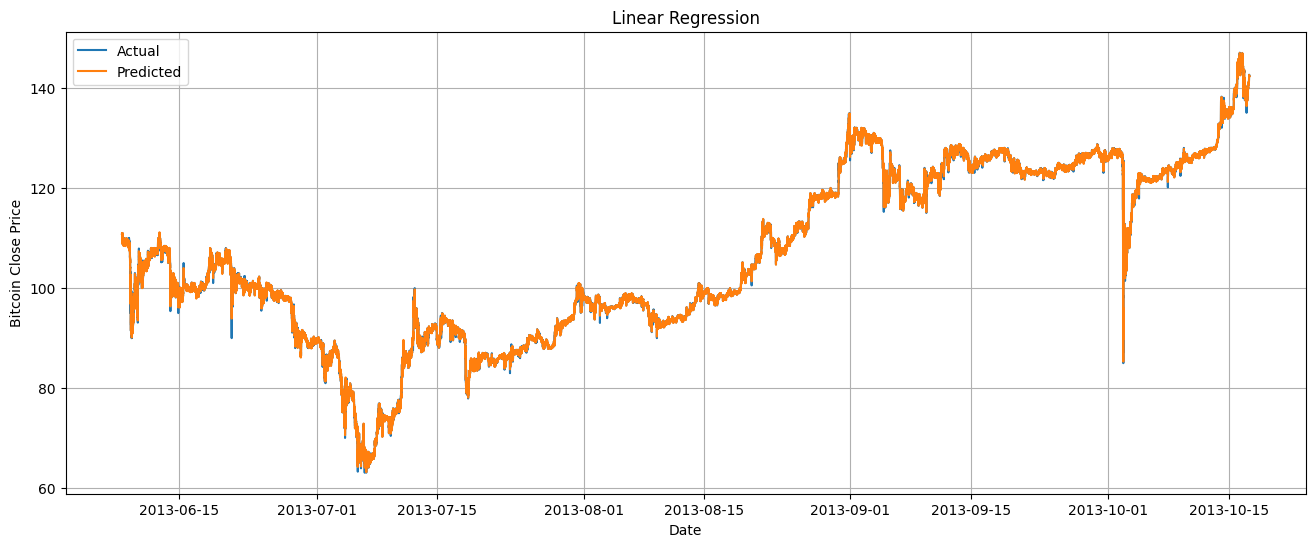

In [62]:
plt.figure(figsize=(16,6))
plt.plot(
lr_pd["Date"],
lr_pd["label"],
label="Actual"
)
plt.plot(
lr_pd["Date"],
lr_pd["prediction"],
label="Predicted"
)
plt.title("Linear Regression")
plt.xlabel("Date")
plt.ylabel("Bitcoin Close Price")
plt.legend()
plt.grid(True)
plt.show()

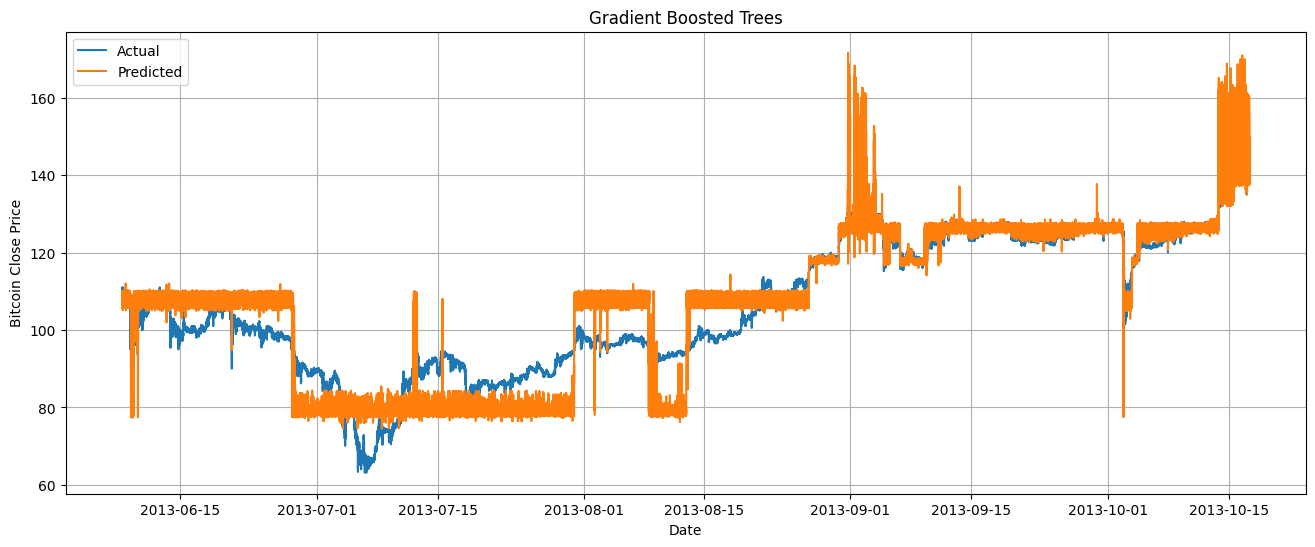

In [63]:
plt.figure(figsize=(16,6))
plt.plot(
gbt_pd["Date"],
gbt_pd["label"],
label="Actual"
)
plt.plot(
gbt_pd["Date"],
gbt_pd["prediction"],
label="Predicted"
)
plt.title("Gradient Boosted Trees")
plt.xlabel("Date")
plt.ylabel("Bitcoin Close Price")
plt.legend()
plt.grid(True)
plt.show()

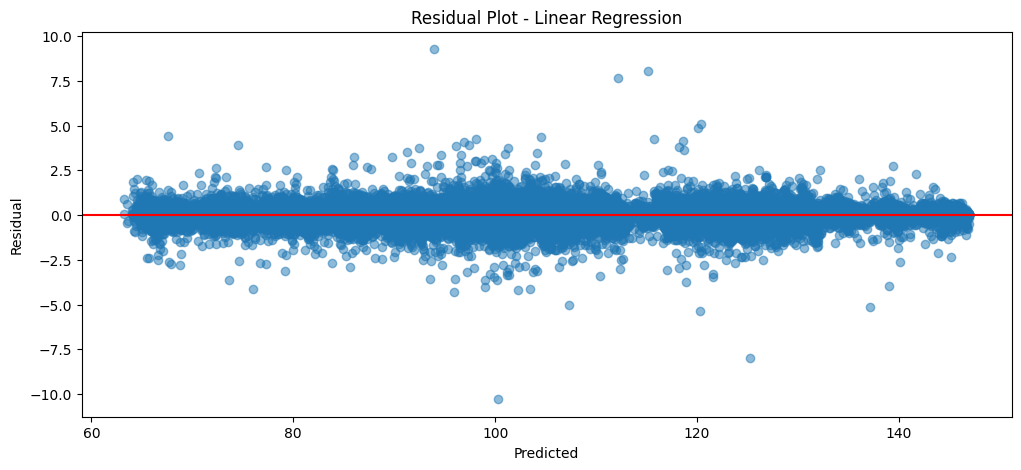

In [65]:
lr_pd["Residual"] = (
lr_pd["label"] -
lr_pd["prediction"]
)
plt.figure(figsize=(12,5))
plt.scatter(
lr_pd["prediction"],
lr_pd["Residual"],
alpha=0.5
)
plt.axhline(
0,
color="red"
)
plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

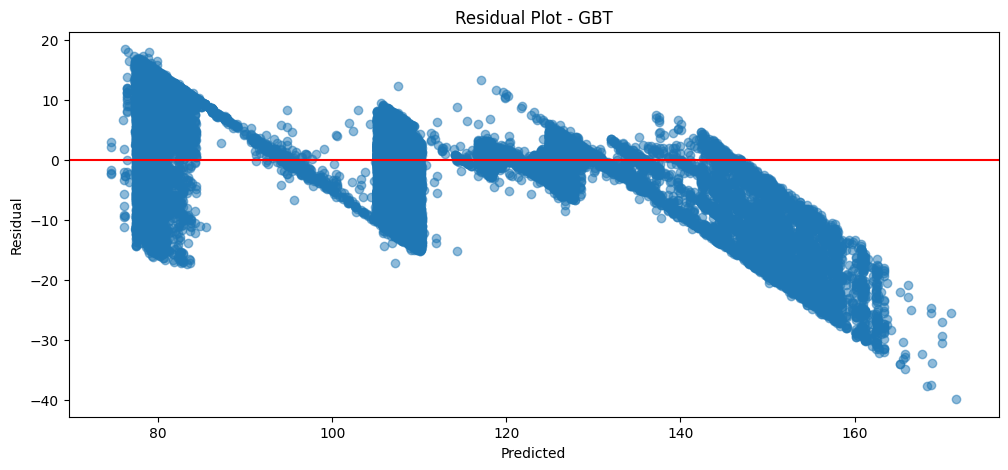

In [68]:
gbt_pd["Residual"] = (
gbt_pd["label"] -
gbt_pd["prediction"]
)
plt.figure(figsize=(12,5))
plt.scatter(
gbt_pd["prediction"],
gbt_pd["Residual"],
alpha=0.5
)
plt.axhline(
0,
color="red"
)
plt.title("Residual Plot - GBT")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

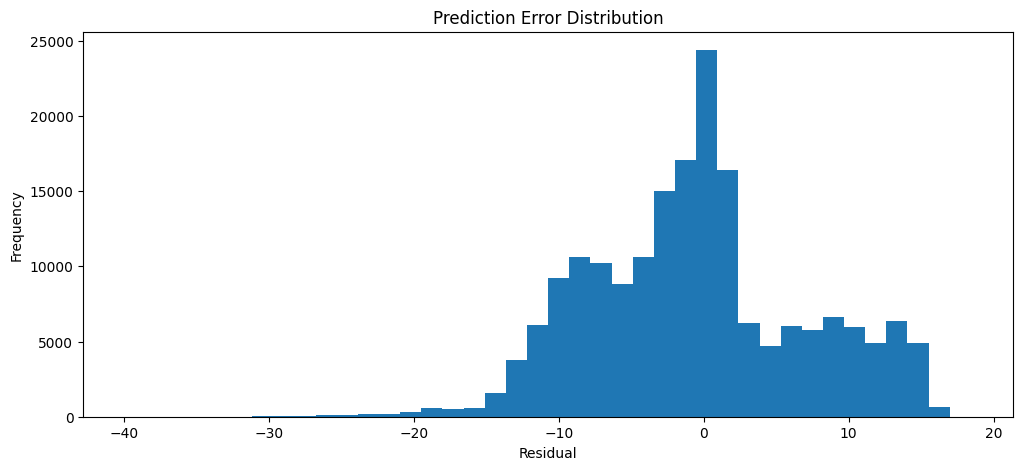

<BarContainer object of 14 artists>

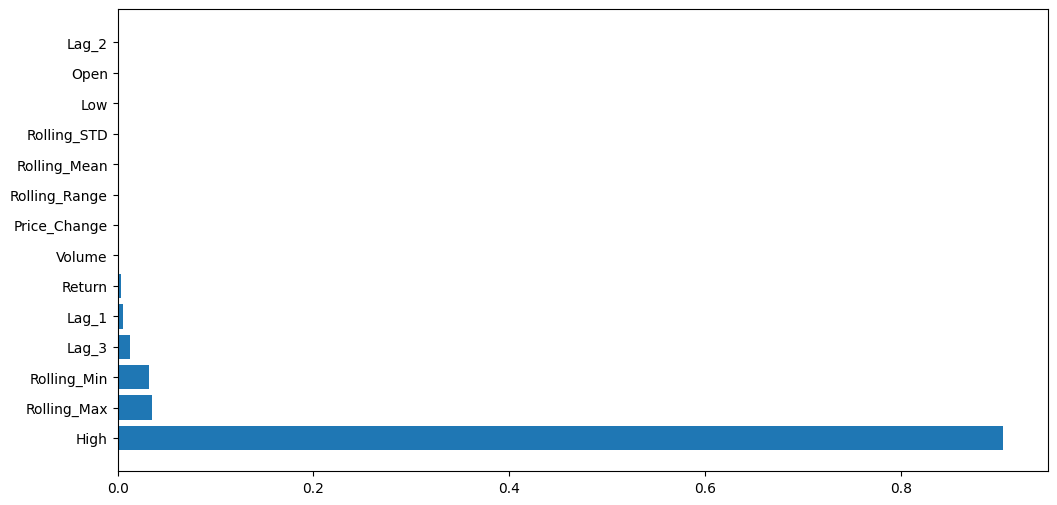

In [69]:
plt.figure(figsize=(12,5))
plt.hist(
gbt_pd["Residual"],
bins=40
)
plt.title("Prediction Error Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()
importance = pd.DataFrame({
"Feature": feature_columns,
"Importance": gbt_model.featureImportances.toArray()
})
importance = importance.sort_values(
by="Importance",
ascending=False
)
importance
plt.figure(figsize=(12,6))
plt.barh(
importance["Feature"],
importance["Importance"]
)